# Autor: Cristian Cabrera

##Clonación del repositorio

In [145]:
!git clone https://github.com/cristiancs1/DataScientistTest.git

Cloning into 'DataScientistTest'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 18 (delta 5), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 1.72 MiB | 5.13 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [146]:
%cd /content/DataScientistTest

/content/DataScientistTest


In [147]:
!pip install catboost

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb, xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy.stats import ks_2samp
import warnings

warnings.filterwarnings('ignore')

#Carga de los datasets

In [190]:
df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

In [191]:
df_train.head()

,id_solicitud,fecha_solicitud,edad,tipo_empleo,ingreso_declarado,antiguedad_laboral_meses,region,canal,antiguedad_cliente_meses,score_buro,...,num_creditos_vigentes,peor_morosidad_12m,num_consultas_buro_3m,num_contactos_ult_trimestre,uso_linea_credito_pct,monto_solicitado,plazo_meses,tasa_interes_anual,dia_semana_solicitud,default_12m
0,100000,2024-07-30,36,dependiente,1307000.0,102.0,Maule,partner,70,559,...,3,0,2,0,11.1,5050000.0,48,22.8,lun,0
1,100001,2024-06-16,63,independiente,782.0,146.0,Biobio,sucursal,76,620,...,1,0,1,1,68.0,590000.0,12,20.7,vie,0
2,100002,2024-08-18,42,independiente,NaN,15.0,Nuble,partner,58,675,...,2,30,1,0,59.2,1440000.0,24,19.2,mar,0
3,100003,2024-04-14,46,independiente,NaN,50.0,Arica,digital,0,728,...,1,0,0,1,49.3,450000.0,12,21.3,vie,0
4,100004,2024-03-08,26,independiente,NaN,41.0,Valparaiso,digital,86,594,...,3,15,0,2,97.5,1170000.0,48,24.9,jue,0


In [192]:
df_test.head()

,id_solicitud,fecha_solicitud,edad,tipo_empleo,ingreso_declarado,antiguedad_laboral_meses,region,canal,antiguedad_cliente_meses,score_buro,deuda_sistema,num_creditos_vigentes,peor_morosidad_12m,num_consultas_buro_3m,num_contactos_ult_trimestre,uso_linea_credito_pct,monto_solicitado,plazo_meses,tasa_interes_anual,dia_semana_solicitud
0,500000,2025-02-14,53,informal,330000.0,NaN,Metropolitana,sucursal,68,784,67000.0,0,0,1,0,0.0,1130000.0,24,19.3,mie
1,500001,2025-02-14,31,dependiente,747.0,21.0,Metropolitana,digital,86,559,352000.0,1,0,2,2,47.3,2000000.0,18,24.7,vie
2,500002,2025-02-14,62,informal,NaN,NaN,Valparaiso,partner,35,517,2545000.0,3,15,1,0,30.7,3040000.0,48,20.9,mie
3,500003,2025-02-14,38,dependiente,463000.0,60.0,Los Lagos,sucursal,26,613,1398000.0,3,60,1,1,53.5,530000.0,24,22.5,vie
4,500004,2025-02-14,37,dependiente,1145000.0,30.0,Valparaiso,digital,74,481,2677000.0,3,0,4,1,52.1,1990000.0,12,19.0,mar


# Descripción de los datos

In [236]:
100*df_train.default_12m.value_counts()/df_train.shape[0]

,count
default_12m,
0,90.068433
1,9.931567


In [193]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45300 entries, 0 to 45299
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_solicitud                 45300 non-null  int64  
 1   fecha_solicitud              45300 non-null  object 
 2   edad                         45300 non-null  int64  
 3   tipo_empleo                  45300 non-null  object 
 4   ingreso_declarado            37095 non-null  float64
 5   antiguedad_laboral_meses     38000 non-null  float64
 6   region                       45300 non-null  object 
 7   canal                        45300 non-null  object 
 8   antiguedad_cliente_meses     45300 non-null  int64  
 9   score_buro                   45300 non-null  int64  
 10  deuda_sistema                45300 non-null  float64
 11  num_creditos_vigentes        45300 non-null  int64  
 12  peor_morosidad_12m           45300 non-null  int64  
 13  num_consultas_bu

In [194]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_solicitud                 12000 non-null  int64  
 1   fecha_solicitud              12000 non-null  object 
 2   edad                         12000 non-null  int64  
 3   tipo_empleo                  12000 non-null  object 
 4   ingreso_declarado            9714 non-null   float64
 5   antiguedad_laboral_meses     10035 non-null  float64
 6   region                       12000 non-null  object 
 7   canal                        12000 non-null  object 
 8   antiguedad_cliente_meses     12000 non-null  int64  
 9   score_buro                   12000 non-null  int64  
 10  deuda_sistema                12000 non-null  float64
 11  num_creditos_vigentes        12000 non-null  int64  
 12  peor_morosidad_12m           12000 non-null  int64  
 13  num_consultas_bu

### Hallazgo: Se visualiza que la variable fecha_solicitud tiene el formato object, por lo que se transformará a su formato correcto.

In [195]:
df_train['fecha_solicitud'] = pd.to_datetime(df_train['fecha_solicitud'])
df_test['fecha_solicitud'] = pd.to_datetime(df_test['fecha_solicitud'])

## Validación de ratio de datos faltantes por variable

In [196]:
100*df_train.isnull().sum()/df_train.shape[0]

,0
id_solicitud,0.000000
fecha_solicitud,0.000000
edad,0.000000
tipo_empleo,0.000000
ingreso_declarado,18.112583
antiguedad_laboral_meses,16.114790
region,0.000000
canal,0.000000
antiguedad_cliente_meses,0.000000
score_buro,0.000000


In [197]:
100*df_test.isnull().sum()/df_test.shape[0]

,0
id_solicitud,0.000
fecha_solicitud,0.000
edad,0.000
tipo_empleo,0.000
ingreso_declarado,19.050
antiguedad_laboral_meses,16.375
region,0.000
canal,0.000
antiguedad_cliente_meses,0.000
score_buro,0.000


## Estadísticas de los datasets

In [198]:
df_train.describe()

,id_solicitud,fecha_solicitud,edad,ingreso_declarado,antiguedad_laboral_meses,antiguedad_cliente_meses,score_buro,deuda_sistema,num_creditos_vigentes,peor_morosidad_12m,num_consultas_buro_3m,num_contactos_ult_trimestre,uso_linea_credito_pct,monto_solicitado,plazo_meses,tasa_interes_anual,default_12m
count,45300.000000,45300,45300.000000,3.709500e+04,38000.000000,45300.000000,45300.000000,4.530000e+04,45300.000000,45300.000000,45300.000000,45300.000000,45300.000000,4.530000e+04,45300.000000,45300.000000,45300.000000
mean,122649.500000,2024-07-23 23:59:27.576158976,39.906799,8.316539e+05,70.227342,47.478102,622.853554,2.489597e+06,1.757483,8.276821,1.129956,0.888720,43.302854,1.703887e+06,22.519470,22.841971,0.099316
min,100000.000000,2024-01-01 00:00:00,19.000000,2.800000e+02,1.000000,0.000000,300.000000,2.800000e+04,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000e+05,6.000000,15.000000,0.000000
25%,111324.750000,2024-04-12 00:00:00,31.000000,5.020000e+05,33.000000,23.000000,559.000000,8.397500e+05,1.000000,0.000000,0.000000,0.000000,25.400000,8.300000e+05,12.000000,21.200000,0.000000
50%,122649.500000,2024-07-25 00:00:00,40.000000,7.760000e+05,59.000000,47.000000,623.000000,1.591000e+06,1.000000,0.000000,1.000000,0.000000,42.200000,1.330000e+06,18.000000,22.900000,0.000000
75%,133974.250000,2024-11-04 00:00:00,48.000000,1.115000e+06,95.000000,71.000000,688.000000,2.998000e+06,3.000000,0.000000,2.000000,1.000000,60.100000,2.140000e+06,24.000000,24.500000,0.000000
max,145299.000000,2025-02-14 00:00:00,133.000000,6.777000e+06,936.000000,95.000000,850.000000,8.000000e+07,10.000000,90.000000,10.000000,12.000000,100.000000,1.500000e+07,48.000000,30.700000,1.000000
std,13077.127934,NaN,12.306937,5.496292e+05,53.053803,27.736528,94.812345,2.993960e+06,1.506263,18.722405,1.308789,1.386357,24.034468,1.335342e+06,11.300589,2.243239,0.299089


In [199]:
df_test.describe()

,id_solicitud,fecha_solicitud,edad,ingreso_declarado,antiguedad_laboral_meses,antiguedad_cliente_meses,score_buro,deuda_sistema,num_creditos_vigentes,peor_morosidad_12m,num_consultas_buro_3m,num_contactos_ult_trimestre,uso_linea_credito_pct,monto_solicitado,plazo_meses,tasa_interes_anual
count,12000.00000,12000,12000.000000,9.714000e+03,10035.000000,12000.000000,12000.000000,1.200000e+04,12000.000000,12000.00000,12000.000000,12000.000000,12000.000000,1.200000e+04,12000.000000,12000.000000
mean,505999.50000,2025-04-23 03:21:21.600000,37.103333,8.353552e+05,65.998406,47.416417,615.697417,2.562670e+06,1.811333,8.61125,1.185083,0.884750,44.220933,1.714904e+06,22.470000,22.976850
min,500000.00000,2025-02-14 00:00:00,19.000000,2.800000e+02,1.000000,0.000000,300.000000,4.500000e+04,0.000000,0.00000,0.000000,0.000000,0.000000,2.000000e+05,6.000000,14.600000
25%,502999.75000,2025-03-20 00:00:00,28.000000,5.070000e+05,30.000000,23.000000,551.000000,8.460000e+05,1.000000,0.00000,0.000000,0.000000,26.400000,8.300000e+05,12.000000,21.400000
50%,505999.50000,2025-04-23 00:00:00,37.000000,7.860000e+05,57.000000,47.000000,615.000000,1.592000e+06,2.000000,0.00000,1.000000,1.000000,43.300000,1.340000e+06,18.000000,23.000000
75%,508999.25000,2025-05-28 00:00:00,45.000000,1.122000e+06,91.000000,72.000000,681.000000,3.077000e+06,3.000000,15.00000,2.000000,1.000000,60.800000,2.160000e+06,24.000000,24.600000
max,511999.00000,2025-06-30 00:00:00,78.000000,5.564000e+06,356.000000,95.000000,850.000000,6.879200e+07,11.000000,90.00000,12.000000,6.000000,100.000000,1.500000e+07,48.000000,31.300000
std,3464.24595,NaN,11.537248,5.404016e+05,46.770049,27.823066,94.582906,3.182740e+06,1.532569,18.85954,1.313382,0.938727,24.077194,1.339939e+06,11.349794,2.243234


##Hallazgos en variables:
###* edad: Se visualizan valores atípicos en los percentiles superiores al 75 en el dataset de train, por lo cual será necesario necesario un tratamiento de outliers.
###* ingreso_declarado: Presenta un importante porcentaje de valores faltantes, lo cual pueda deberse a personas sin empleo, que no lo declaran por temor a rechazos, porque son informales, emprendedores u otros motivos, además se visualizan valores atípicos, como un monto del 280 clp, lo cual es inconsiste para el caso, esto podría deberse a errores de digitación, por lo que será necesario realizar un análisis gráfico de la variable y realizar una transformación.

###* antiguedad_laboral_meses: al igual que la variable ingreso_declarado, presenta datos faltantes, tal vez por que no tienen empleo, son informales u otros motivos, también muestra valores máximos atípicos, por lo cual también se debe realizar un análisis y tratamiento.

###* peor_morosidad_12m: En ambos datasets, se pueden notar que la mayor parte de sus valores son ceros, por lo cual, se debe validar si esta variable aportará al entrenamiento del modelo o si se debe descartar.

###* deuda_sistema: Se puede visualizar que esta variable contiene valores máximos extremadamente altos, por lo cual es necesario realizar un tratamiento de valores atípicos.

###* num_contactos_ult_trimestre: Dado que queremos predecir la probabilidad de riesgo con datos actuales, esta variable no aportaría al modelo, ya que si vemos que hay clientes con varios contactos, significa que tiene morosidad, lo cual es cierto, sin embargo, al intentar predecir el riesgo de un cliente nuevo, al no encontrar este valor, podría clasificar erróneamente. Por lo tanto, esta variable no se considerará.

## Analizando la variable edad

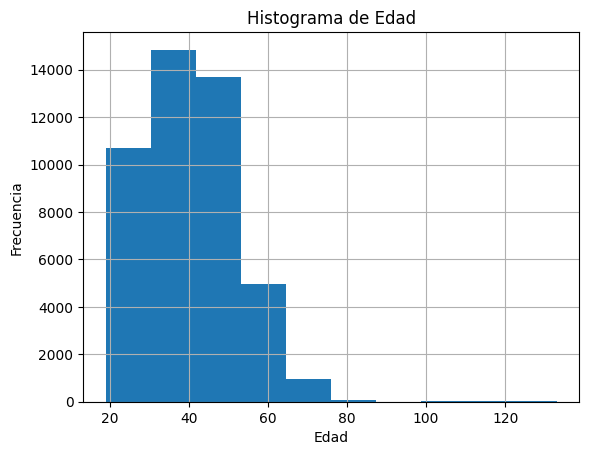

In [200]:
df_train['edad'].hist()

plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Histograma de Edad')
plt.show()

##Hallazgo: Se puede visualizar que la mayor parte de clientes se concentran entre los 19 años y alrededor de 75 años, denotandose los demás como valores atípicos.

In [201]:
def detectar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Filtramos los datos que están fuera de estos límites
    outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]
    outliers_lim_inf = df[(df[columna] < limite_inferior)]
    outliers_lim_sup = df[(df[columna] > limite_superior)]

    print("Cantidad de valores atípicos: ", len(outliers))
    print("Limite inferior: ", limite_inferior)
    print("Limite superior: ", limite_superior)
    print("Cantidad de valores atípicos por debajo del límite inferior: ", len(outliers_lim_inf))
    print("Cantidad de valores atípicos por debajo del límite inferior: ", len(outliers_lim_sup))

detectar_outliers_iqr(df_train, 'edad')

Cantidad de valores atípicos:  226
Limite inferior:  5.5
Limite superior:  73.5
Cantidad de valores atípicos por debajo del límite inferior:  0
Cantidad de valores atípicos por debajo del límite inferior:  226


##Decisión: Se aplicará la técnica de Winsorización, reemplazando las edad superiores a 74 años (valor redondeado del límite superior) por este mismo valor, a fin de evitar la eliminación de estos casos y evitar que estos valores atípicos distorsionen los entrenamiento de los modelos. Con este analisis, también validamos lo obtenido en el histograma graficado anteriormente. Con respecto al límite inferior (5.5), no es factible considerar esta edad, ya que se requiere ser mayor de edad para solicitar un crédito, por lo tanto se definirá como límite inferior 18 años.

In [202]:
lim_inf = 18
lim_sup = 74

df_train['edad'] = df_train['edad'].clip(lower=lim_inf, upper=lim_sup)
df_test['edad'] = df_test['edad'].clip(lower=lim_inf, upper=lim_sup)

## Analizando la variable ingreso_declarado

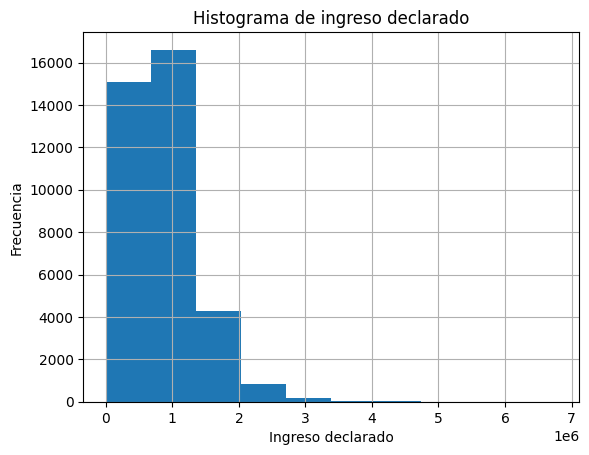

In [203]:
df_train['ingreso_declarado'].hist()

plt.xlabel('Ingreso declarado')
plt.ylabel('Frecuencia')
plt.title('Histograma de ingreso declarado')
plt.show()

In [204]:
df_train[df_train['ingreso_declarado'] < 100000]['ingreso_declarado'].value_counts()

,count
ingreso_declarado,
280.0,68
693.0,12
613.0,11
704.0,11
706.0,10
...,...
1782.0,1
1756.0,1
2190.0,1


### Hallazgo y decisión: Se observa una gran cantidad de valores menores a $100000, con lo cual se valida que estos casos pueden ser errores de tipeo. Por lo tanto, estos valores serán multiplicados por 1000.

In [205]:
mask = (df_train['ingreso_declarado'] < 100000)
# Aplicar la corrección solo donde se cumple la condición
df_train.loc[mask, 'ingreso_declarado'] = df_train.loc[mask, 'ingreso_declarado'] * 1000
df_test.loc[mask, 'ingreso_declarado'] = df_test.loc[mask, 'ingreso_declarado'] * 1000

## Decisión: Con respecto a los valores faltantes, estos se mantendrán, debido a que son manejables por los algoritmos que usaré para el modelamiento. Adicionalmente se creará una variable que indica si un cliente declaró sus ingresos, a fin de que ambas variables se puedan complementar.

In [206]:
df_train['falta_ingreso_declarado'] = df_train['ingreso_declarado'].isna().astype(int)
df_test['falta_ingreso_declarado'] = df_test['ingreso_declarado'].isna().astype(int)

## Analizando la variable antiguedad_laboral_meses

In [207]:
detectar_outliers_iqr(df_train, 'antiguedad_laboral_meses')

Cantidad de valores atípicos:  1108
Limite inferior:  -60.0
Limite superior:  188.0
Cantidad de valores atípicos por debajo del límite inferior:  0
Cantidad de valores atípicos por debajo del límite inferior:  1108


### Decisión: Al igual que en el caso de la variable edad, vamos a aplicar la técnica de winsorización, definiendo como límite superior a 188 meses, el cual es un valor más realista y como límite inferior 0, ya que no pueden existir valores negativos para esta variable.

In [208]:
lim_inf = 0
lim_sup = 188

df_train['antiguedad_laboral_meses'] = df_train['antiguedad_laboral_meses'].clip(lower=lim_inf, upper=lim_sup)
df_test['antiguedad_laboral_meses'] = df_test['antiguedad_laboral_meses'].clip(lower=lim_inf, upper=lim_sup)

## Decisión: Con respecto a los valores faltantes, Con respecto a los valores faltantes, estos se mantendrán, debido a que son manejables por los algoritmos que usaré para el modelamiento. Adicionalmente se creará una variable que indica si un cliente con cuenta antiguedad laboral, a fin de que ambas variables se puedan complementar.

In [209]:
df_train['falta_antiguedad_laboral'] = df_train['antiguedad_laboral_meses'].isna().astype(int)
df_test['falta_antiguedad_laboral'] = df_test['antiguedad_laboral_meses'].isna().astype(int)

## Analizando la variable peor_morosidad_12m

In [210]:
# Ver los valores únicos de esta variable para entender la escala real
print(100*df_train['peor_morosidad_12m'].value_counts().sort_index(ascending=False).head(10)/df_train.shape[0])

peor_morosidad_12m
90     2.337748
60     3.885210
30     7.150110
15    11.311258
0     75.315673
Name: count, dtype: float64


### Decisión: Dado que la variable cuenta con valores que delimitan rangos exactos de dias, la variable se mantenderá, ya que al eliminarla se podría perder datos de valor. Sin embargo, se creará una variable flag que permita identificar si un cliente ha tenido mora en los últimos 12 meses, a fin de que puedan complementarse.

In [211]:
df_train['flag_mora_12m'] = (df_train['peor_morosidad_12m'] > 0).astype(int)
df_test['flag_mora_12m'] = (df_test['peor_morosidad_12m'] > 0).astype(int)

## Analizando la variable deuda_sistema

In [212]:
df_train[df_train['deuda_sistema'] > df_train['deuda_sistema'].quantile(0.75)]['deuda_sistema'].value_counts().reset_index().sort_values(by='deuda_sistema')

,deuda_sistema,count
269,2999000.0,5
162,3000000.0,6
4,3001000.0,11
83,3002000.0,7
253,3003000.0,5
...,...,...
5131,53137000.0,1
4981,54896000.0,1
4576,66157000.0,1
3437,76639000.0,1


## Decisión: Se realizará la técnica de Winsorización, pero reemplazando a aquellos valores superiores al percentil 99 de esta variable por el valor de este percentil. Esta es una estrategia estandar en el negocio financiero, tratar estos casos atípicos, sin afectar a los clientes cuyos datos son reales.

In [213]:
# Calcular el percentil 99 del train
limite_deuda = df_train['deuda_sistema'].quantile(0.99)

# Aplicar capping (Winsorization) al train Y al test
df_train['deuda_sistema'] = df_train['deuda_sistema'].clip(upper=limite_deuda)
df_test['deuda_sistema'] = df_test['deuda_sistema'].clip(upper=limite_deuda)

## Analizando consistencia de variables categóricas

In [214]:
df_train.tipo_empleo.unique()

array(['dependiente', 'independiente', 'informal', 'jubilado'],
      dtype=object)

In [215]:
df_train.region.unique()

array(['Maule', 'Biobio', 'Nuble', 'Arica', 'Valparaiso', 'Metropolitana',
       'Magallanes', 'OHiggins', 'Araucania', 'Antofagasta', 'Coquimbo',
       'Los Lagos', 'Los Rios', 'Tarapaca', 'Atacama', 'Aysen'],
      dtype=object)

In [216]:
df_train.canal.unique()

array(['partner', 'sucursal', 'digital'], dtype=object)

In [217]:
df_train.dia_semana_solicitud.unique()

array(['lun', 'vie', 'mar', 'jue', 'mie', 'sab', 'dom'], dtype=object)

## Hallazgo: Todas las variables categóricas cuentan con valores consistentes y a fines a sus contextos, por lo cual no será necesario realizar alguna transformación de limpieza.

##Creación de nuevas variables

### * ratio_endeudamiento: Se crea esta variable debido a que a las entidades les puede interesar la deuda con respecto al ingreso. Además nos permite identificar el riesgo real de sobreendeudamiento, mejorando la precisión del modelo al evaluar la capacidad de pago del cliente de manera integral.

In [219]:
# Crear ratio de endeudamiento (evitando división por cero)
df_train['ratio_endeudamiento'] = df_train['deuda_sistema'] / (df_train['ingreso_declarado'])
df_train['ratio_endeudamiento'] = df_train['ratio_endeudamiento'].replace([np.inf, -np.inf], np.nan)

df_test['ratio_endeudamiento'] = df_train['deuda_sistema'] / (df_train['ingreso_declarado'])
df_test['ratio_endeudamiento'] = df_test['ratio_endeudamiento'].replace([np.inf, -np.inf], np.nan)

### * ratio_endeudamiento_post: También se propone esta variable, en la cual se le suma el monto solicitado a la deuda del cliente, con lo cual se tiene un ratio post desembolso.

In [220]:
# Crear ratio de endeudamiento (evitando división por cero)
df_train['ratio_endeudamiento_post'] = (df_train['deuda_sistema']+df_train['monto_solicitado']) / (df_train['ingreso_declarado'])
df_train['ratio_endeudamiento_post'] = df_train['ratio_endeudamiento_post'].replace([np.inf, -np.inf], np.nan)

df_test['ratio_endeudamiento_post'] = (df_train['deuda_sistema']+df_train['monto_solicitado']) / (df_train['ingreso_declarado'])
df_test['ratio_endeudamiento_post'] = df_test['ratio_endeudamiento_post'].replace([np.inf, -np.inf], np.nan)

### * ratio_deuda_nueva: Permite medir la fracción de la deuda total de ada cliente post desembolso. Los valores cercanos a 1 identifican a clientes con poca deuda y con mayor foco en el reciente crédito y valores cercanos a 0, denota a clientes con otras deudas sumadas a esta nueva deuda.

In [221]:
df_train['ratio_deuda_nueva'] = df_train['monto_solicitado'] / (df_train['deuda_sistema'] + df_train['monto_solicitado'])
df_test['ratio_deuda_nueva'] = df_test['monto_solicitado'] / (df_test['deuda_sistema'] + df_test['monto_solicitado'])

## Selección de variables y datasets

In [222]:
# Columnas que NO entran al modelo: identificadores, target, fecha y la variable con FUGA
# (num_contactos_ult_trimestre registra cobranza posterior al desembolso -> se excluye)
excluir = ['id_solicitud', 'fecha_solicitud', 'default_12m', 'num_contactos_ult_trimestre']
features = [c for c in df_train.columns if c not in excluir]

categoricas = ['tipo_empleo', 'region', 'canal', 'dia_semana_solicitud']
for c in categoricas:
    df_train[c] = df_train[c].astype('category')
    df_test[c]  = df_test[c].astype('category')

In [223]:
print("Fecha de solicitud mínima: ", df_train.fecha_solicitud.min())
print("Fecha de solicitud máxima: ", df_train.fecha_solicitud.max())

Fecha de solicitud mínima:  2024-01-01 00:00:00
Fecha de solicitud máxima:  2025-02-14 00:00:00


In [224]:
#Definimos una fecha de corte para los datasets de entrenamiento y validación
corte = df_train['fecha_solicitud'] <= '2024-10-31'
X_ent, y_ent = df_train.loc[corte, features], df_train.loc[corte, 'default_12m']
X_val, y_val = df_train.loc[~corte, features], df_train.loc[~corte, 'default_12m']

print(f'Entrenamiento: {len(X_ent):,} filas | default {y_ent.mean():.1%}')
print(f'Validación   : {len(X_val):,} filas | default {y_val.mean():.1%}')

Entrenamiento: 33,629 filas | default 9.1%
Validación   : 11,671 filas | default 12.3%


## Modelamiento

In [225]:
resultados, modelos = {}, {}

#LightGBM con categóricas nativas (dtype category)
m_lgb = lgb.LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        min_child_samples=100, # 50 se eligió trabajar con 100, ya que al utilizar 50, crea hojas con pocos registros y se requieren de mayor estabilidad para tener un modelo más estable
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=5.0,
        eval_metric="auc",
        random_state=101,
        verbose=-1)
m_lgb.fit(X_ent, y_ent, categorical_feature=categoricas)
modelos['LightGBM'] = m_lgb
resultados['LightGBM'] = m_lgb.predict_proba(X_val)[:, 1]

In [226]:
#XGBoost con soporte nativo de categóricas (enable_categorical)
m_xgb = xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=100, #5, se utiliza 100 para evitar sobreajuste
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        random_state=101,
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        verbose=-1)
m_xgb.fit(X_ent, y_ent)
modelos['XGBoost'] = m_xgb
resultados['XGBoost'] = m_xgb.predict_proba(X_val)[:, 1]

In [227]:
#CatBoost: categóricas por nombre, se pasan como strings porque no admite NaN en ellas
X_ent_cb, X_val_cb = X_ent.copy(), X_val.copy()
for c in categoricas:
    X_ent_cb[c] = X_ent_cb[c].astype(str)
    X_val_cb[c] = X_val_cb[c].astype(str)

m_cat = CatBoostClassifier(
        iterations=800,
        learning_rate=0.03,
        depth=5,
        l2_leaf_reg=5.0,
        random_strength=1,
        bagging_temperature=1,
        border_count=64,
        auto_class_weights="Balanced",
        loss_function="Logloss",
        random_seed=101)
m_cat.fit(X_ent_cb, y_ent, cat_features=categoricas)
modelos['CatBoost'] = m_cat
resultados['CatBoost'] = m_cat.predict_proba(X_val_cb)[:, 1]



0:	learn: 0.6812535	total: 27.7ms	remaining: 22.1s
1:	learn: 0.6718295	total: 55ms	remaining: 22s
2:	learn: 0.6620094	total: 79.9ms	remaining: 21.2s
3:	learn: 0.6538133	total: 104ms	remaining: 20.6s
4:	learn: 0.6452204	total: 131ms	remaining: 20.9s
5:	learn: 0.6361365	total: 158ms	remaining: 20.8s
6:	learn: 0.6280644	total: 185ms	remaining: 20.9s
7:	learn: 0.6209712	total: 205ms	remaining: 20.3s
8:	learn: 0.6133896	total: 235ms	remaining: 20.6s
9:	learn: 0.6068689	total: 260ms	remaining: 20.5s
10:	learn: 0.6000196	total: 288ms	remaining: 20.6s
11:	learn: 0.5937974	total: 314ms	remaining: 20.6s
12:	learn: 0.5880284	total: 338ms	remaining: 20.5s
13:	learn: 0.5829037	total: 364ms	remaining: 20.4s
14:	learn: 0.5779551	total: 389ms	remaining: 20.3s
15:	learn: 0.5727652	total: 426ms	remaining: 20.9s
16:	learn: 0.5685002	total: 458ms	remaining: 21.1s
17:	learn: 0.5637781	total: 483ms	remaining: 21s
18:	learn: 0.5601333	total: 508ms	remaining: 20.9s
19:	learn: 0.5570635	total: 536ms	remaining:

In [228]:
tabla = pd.DataFrame({
    'AUC':   {k: roc_auc_score(y_val, p) for k, p in resultados.items()},
    "Gini": {k: 2*roc_auc_score(y_val,p)-1 for k,p in resultados.items()},
    'Brier': {k: brier_score_loss(y_val, p) for k, p in resultados.items()},
    'prob_media': {k: p.mean() for k, p in resultados.items()},
    "KS": {k: ks_2samp(p[y_val==1], p[y_val==0]).statistic for k,p in resultados.items()
    },
}).sort_values('AUC', ascending=False)
print(tabla.round(3))
print(f'(default observado en validación: {y_val.mean():.4f})')

            AUC   Gini  Brier  prob_media     KS
XGBoost   0.837  0.675  0.085       0.100  0.511
CatBoost  0.836  0.672  0.158       0.344  0.511
LightGBM  0.835  0.670  0.086       0.098  0.517
(default observado en validación: 0.1225)


## Conclusión: XGBoost es el modelo óptimo al liderar en capacidad de ordenamiento (AUC de 0.837 / Gini de 0.675) y ofrecer la mejor calibración probabilística para riesgo de crédito, registrando el menor Brier Score (0.085) con una probabilidad media cercana al default real.

In [229]:
mejor = tabla.index[0]
print("Modelo elegido: ",mejor)

Modelo elegido:  XGBoost


In [230]:
def economia(df):
    G = df.monto_solicitado * 0.12 * (df.plazo_meses / 12) * 0.5   # ganancia si paga
    L = df.monto_solicitado * 0.55                                 # pérdida si default (LGD)
    umbral = G / (G + L)   # aprobar si prob < umbral (donde el valor esperado es positivo)
    return G, L, umbral

# Evaluación sobre la validación con los defaults REALES observados
val = df_train.loc[~corte].copy()
val['p'] = resultados[mejor]
G, L, umbral = economia(val)
resultado_real = np.where(val.default_12m == 1, -L, G)   # ganancia/pérdida real por crédito
aprueba = val.p < umbral

print('Umbral de aprobación por plazo (prob. máxima aceptada):')
print({p: f'{0.005*p/(0.005*p+0.55):.1%}' for p in sorted(val.plazo_meses.unique())})
print(f'\nLa política aprueba el {aprueba.mean():.0%} de las solicitudes')
print(f'Default de la cartera aprobada: {val.default_12m[aprueba].mean():.1%} '
      f'(vs {val.default_12m.mean():.1%} aprobando todo)')
print(f'\nGanancia aprobando todo : {resultado_real.sum()/1e6:>7,.0f} MM CLP')
print(f'Ganancia con la política: {resultado_real[aprueba].sum()/1e6:>7,.0f} MM CLP')
print(f'Mejora: {(resultado_real[aprueba].sum()-resultado_real.sum())/1e6:,.0f} MM CLP '
      f'({resultado_real[aprueba].sum()/resultado_real.sum()-1:+.0%})')

Umbral de aprobación por plazo (prob. máxima aceptada):
{np.int64(6): '5.2%', np.int64(12): '9.8%', np.int64(18): '14.1%', np.int64(24): '17.9%', np.int64(36): '24.7%', np.int64(48): '30.4%'}

La política aprueba el 79% de las solicitudes
Default de la cartera aprobada: 5.9% (vs 12.3% aprobando todo)

Ganancia aprobando todo :     337 MM CLP
Ganancia con la política:   1,083 MM CLP
Mejora: 745 MM CLP (+221%)


###Conclusiones: Se puede visualizar que según los plazos en meses, a corto plazo (6 meses) el umbral de aprobación es del 5.2% y este va aumentando según aumente el plazo, es decir, a mayor plazo, mayor aceptación de clientes con riesgos más altos. Además, con la política, se obtiene una mayor ganancia (+221%)

## Obtención de probabilidades a partir del dataset de test

In [231]:
m_final = xgb.XGBClassifier(
        n_estimators=800,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=100,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        random_state=101,
        enable_categorical=True,
        tree_method='hist',
        eval_metric='auc',
        verbose=-1)

m_final.fit(df_train[features], df_train['default_12m'])
prob_test = m_final.predict_proba(df_test[features])[:, 1]

In [232]:
pred = pd.DataFrame({'id_solicitud': df_test.id_solicitud, 'prob_default': prob_test})
assert len(pred) == 12000 and pred.id_solicitud.is_unique and pred.prob_default.between(0, 1).all()
pred.to_csv('predictions.csv', index=False)
print(f'predictions.csv generado: {len(pred):,} filas | prob. media: {prob_test.mean():.1%}')
pred.head()

predictions.csv generado: 12,000 filas | prob. media: 10.6%


,id_solicitud,prob_default
0,500000,0.003916
1,500001,0.080897
2,500002,0.343714
3,500003,0.081703
4,500004,0.273028


In [233]:
G_te, L_te, umbral_te = economia(df_test)
ve_test = (1 - prob_test) * G_te - prob_test * L_te   # valor esperado por solicitud
aprueba_te = prob_test < umbral_te
print(f'La política aprobaría el {aprueba_te.mean():.0%} de las 12.000 solicitudes de test')
print(f'Ganancia esperada con política : {ve_test[aprueba_te].sum()/1e6:,.0f} MM CLP')
print(f'Ganancia esperada aprobar todo : {ve_test.sum()/1e6:,.0f} MM CLP')
print(f'Mejora: {(ve_test[aprueba_te].sum() -ve_test.sum())/1e6:,.0f} MM CLP '
      f'({ve_test[aprueba_te].sum()/ve_test.sum()-1:+.0%})')

La política aprobaría el 77% de las 12.000 solicitudes de test
Ganancia esperada con política : 1,286 MM CLP
Ganancia esperada aprobar todo : 693 MM CLP
Mejora: 593 MM CLP (+86%)
